# Prompt Ablation - Accuracy & Self-Consistency by Prompt Template x Model
3 prompt templates x 5 models at `poison_rate=0.5`, k=5. Phase 1: accuracy (temp=0, N=50). Phase 2: self-consistency (temp=0.7, sc_runs=5, N=30).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
POISON_RATE     = 0.5   # fixed for this ablation

# Phase 1 - accuracy (temperature=0, deterministic)
TEMP_ACC        = cfg["models"]["temperature"]        # 0.0
N_ACC           = 5 if DRY_RUN else cfg["evaluation"]["n_examples"]   # 50

# Phase 2 - self-consistency (temperature > 0, multiple runs)
TEMP_SC         = cfg["models"]["temperature_consistency"]            # 0.7
SC_RUNS         = 2 if DRY_RUN else cfg["evaluation"]["self_consistency_runs"]  # 5
N_SC            = 5 if DRY_RUN else cfg["evaluation"]["self_consistency_subset"] # 30


total_acc_calls = len(PROMPT_TYPES) * len(MODELS) * N_ACC
total_sc_calls  = len(PROMPT_TYPES) * len(MODELS) * N_SC * SC_RUNS
print(f"DRY_RUN={DRY_RUN}  POISON_RATE={POISON_RATE}")
print(f"Phase 1 - accuracy:          {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_ACC} examples = {total_acc_calls} calls (cached from nb05)")
print(f"Phase 2 - self-consistency:  {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_SC} examples × {SC_RUNS} runs = {total_sc_calls} new calls")

from nb_style import MODEL_LABELS, MODEL_COLORS


DRY_RUN=False  POISON_RATE=0.5
Phase 1 - accuracy:          3 prompts × 5 models × 50 examples = 750 calls (cached from nb05)
Phase 2 - self-consistency:  3 prompts × 5 models × 30 examples × 5 runs = 2250 new calls


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples_acc = all_examples[:N_ACC]
examples_sc  = all_examples[:N_SC]

# Pre-poison at the fixed rate; same seed → same passages as nb03 (guaranteed cache hits)
poisoned_acc = poison_dataset(examples_acc, poison_rate=POISON_RATE, seed=SEED)
poisoned_sc  = poison_dataset(examples_sc,  poison_rate=POISON_RATE, seed=SEED)

print(f"Accuracy pool:          {len(poisoned_acc)} examples")
print(f"Self-consistency pool:  {len(poisoned_sc)} examples")

Accuracy pool:          50 examples
Self-consistency pool:  30 examples


In [3]:
def build_llm(model: str, temperature: float):
    return HuggingFaceClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)


def run_ablation_sweep(examples, prompt_types, models, k, embedder, temperature,
                       distractor_pool, seed, sc_runs=1):
    """Run prompt_types × models sweep; return list of metric dicts."""
    rows = []
    for model_name in models:
        print(f"\n--- Model: {model_name} (temp={temperature}) ---")
        llm = build_llm(model_name, temperature)
        with llm:
            for prompt_type in prompt_types:
                retriever = Retriever(embedder=embedder, k=k)
                metrics = run_scorer(
                    examples=examples,
                    retriever=retriever,
                    llm=llm,
                    prompt_type=prompt_type,
                    distractor_pool_size=distractor_pool,
                    seed=seed,
                    self_consistency_runs=sc_runs,
                )
                rows.append({"model": model_name, "prompt_type": prompt_type, **metrics})
                sc_str = f"  sc={metrics.get('self_consistency', float('nan')):.3f}" if sc_runs > 1 else ""
                cdr_str = f"  cdr={metrics['contradiction_detection_rate']:.3f}" if "contradiction_detection_rate" in metrics else ""
                print(
                    f"  prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
                    f"  f1={metrics['macro_f1']:.3f}"
                    f"  hall={metrics['hallucination_rate']:.3f}{sc_str}{cdr_str}"
                )
    return rows

## Phase 1 - Accuracy Ablation (temperature=0, N=50)

In [4]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)

print("Phase 1 - accuracy sweep (poison_rate=0.5, temperature=0) ...")
acc_rows = run_ablation_sweep(
    examples=poisoned_acc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_ACC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=1,
)
df_acc = pd.DataFrame(acc_rows)
print(f"\nPhase 1 done. {len(df_acc)} conditions.")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Phase 1 - accuracy sweep (poison_rate=0.5, temperature=0) ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct (temp=0.0) ---
  prompt=standard         acc=0.500  f1=0.442  hall=0.059
  prompt=chain_of_thought  acc=0.500  f1=0.431  hall=0.000
  prompt=vigilant         acc=0.320  f1=0.162  hall=0.059  cdr=0.000

--- Model: google/gemma-2-2b-it (temp=0.0) ---
  prompt=standard         acc=0.600  f1=0.578  hall=0.118
  prompt=chain_of_thought  acc=0.480  f1=0.429  hall=0.059
  prompt=vigilant         acc=0.440  f1=0.352  hall=0.118  cdr=0.000

--- Model: HuggingFaceTB/SmolLM2-1.7B-Instruct (temp=0.0) ---
  prompt=standard         acc=0.340  f1=0.169  hall=0.000
  prompt=chain_of_thought  acc=0.300  f1=0.226  hall=0.294
  prompt=vigilant         acc=0.520  f1=0.506  hall=0.588  cdr=0.000

--- Model: microsoft/Phi-3.5-mini-instruct (temp=0.0) ---
  prompt=standard         acc=0.600  f1=0.599  hall=0.294
  prompt=chain_of_thought  acc=0.620  f1=0.619  hall=0.294
  prompt=vigilant         acc=0.520  f1

## Phase 2 - Self-Consistency (temperature=0.7, N=30, sc_runs=5)

In [5]:
print(f"Phase 2 - self-consistency sweep (poison_rate={POISON_RATE}, temp={TEMP_SC}, sc_runs={SC_RUNS}) ...")
sc_rows = run_ablation_sweep(
    examples=poisoned_sc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_SC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=SC_RUNS,
)
embedder.close()

df_sc = pd.DataFrame(sc_rows)[["model", "prompt_type", "self_consistency"]]
print(f"\nPhase 2 done. {len(df_sc)} conditions.")

Phase 2 - self-consistency sweep (poison_rate=0.5, temp=0.7, sc_runs=5) ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct (temp=0.7) ---
  prompt=standard         acc=0.400  f1=0.302  hall=0.000  sc=0.733
  prompt=chain_of_thought  acc=0.567  f1=0.436  hall=0.125  sc=0.807
  prompt=vigilant         acc=0.267  f1=0.148  hall=0.000  sc=0.860  cdr=0.000

--- Model: google/gemma-2-2b-it (temp=0.7) ---
  prompt=standard         acc=0.600  f1=0.510  hall=0.250  sc=0.900
  prompt=chain_of_thought  acc=0.600  f1=0.462  hall=0.000  sc=0.780
  prompt=vigilant         acc=0.267  f1=0.193  hall=0.125  sc=0.753  cdr=0.000

--- Model: HuggingFaceTB/SmolLM2-1.7B-Instruct (temp=0.7) ---
  prompt=standard         acc=0.333  f1=0.231  hall=0.000  sc=0.773
  prompt=chain_of_thought  acc=0.433  f1=0.392  hall=0.375  sc=0.707
  prompt=vigilant         acc=0.333  f1=0.231  hall=0.000  sc=0.713  cdr=0.000

--- Model: microsoft/Phi-3.5-mini-instruct (temp=0.7) ---
  prompt=standard         acc=0.567  f1=0.537  hall=

## Combined Ablation Table

In [6]:
df = df_acc.merge(df_sc, on=["model", "prompt_type"], how="left")

# Short model names for display
df["model_short"] = df["model"].apply(lambda x: x.split("-")[0])

display_cols = ["model", "prompt_type", "accuracy", "macro_f1", "hallucination_rate",
                "self_consistency", "contradiction_detection_rate"]
# contradiction_detection_rate is only present for vigilant rows; NaN elsewhere
table = df[[c for c in display_cols if c in df.columns]].copy()
table = table.set_index(["model", "prompt_type"])
col_rename = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "hallucination_rate": "Hallucination Rate",
    "self_consistency": "Self-Consistency",
    "contradiction_detection_rate": "Contradiction Detection Rate",
}
table.columns = [col_rename.get(c, c) for c in table.columns]
table.index = table.index.map(lambda x: (x[0].split("-")[0], x[1]))

print(f"=== Prompt Ablation Table (poison_rate={POISON_RATE}, k={K}) ===")
print(table.to_string(float_format="{:.3f}".format))

=== Prompt Ablation Table (poison_rate=0.5, k=5) ===
                                        Accuracy  Macro-F1  Hallucination Rate  Self-Consistency  Contradiction Detection Rate
model                 prompt_type                                                                                             
Qwen/Qwen2.5          standard             0.500     0.442               0.059             0.733                           NaN
                      chain_of_thought     0.500     0.431               0.000             0.807                           NaN
                      vigilant             0.320     0.162               0.059             0.860                         0.000
google/gemma          standard             0.600     0.578               0.118             0.900                           NaN
                      chain_of_thought     0.480     0.429               0.059             0.780                           NaN
                      vigilant             0.440     0.352

In [7]:
# Pivot: rows = prompt_type, columns = model
pivot_acc = df.pivot_table(
    index="prompt_type", columns="model_short", values="accuracy"
)
pivot_f1 = df.pivot_table(
    index="prompt_type", columns="model_short", values="macro_f1"
)
pivot_hall = df.pivot_table(
    index="prompt_type", columns="model_short", values="hallucination_rate"
)
pivot_sc = df.pivot_table(
    index="prompt_type", columns="model_short", values="self_consistency"
)

print("=== Accuracy (↑ better) ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))
print("\n=== Macro-F1 (↑ better) ===")
print(pivot_f1.to_string(float_format="{:.3f}".format))
print("\n=== Hallucination Rate (↓ better) ===")
print(pivot_hall.to_string(float_format="{:.3f}".format))
print("\n=== Self-Consistency (↑ better) ===")
print(pivot_sc.to_string(float_format="{:.3f}".format))

=== Accuracy (↑ better) ===
model_short       HuggingFaceTB/SmolLM2  Qwen/Qwen2.5  google/gemma  meta  microsoft/Phi
prompt_type                                                                             
chain_of_thought                  0.300         0.500         0.480 0.400          0.620
standard                          0.340         0.500         0.600 0.480          0.600
vigilant                          0.520         0.320         0.440 0.320          0.520

=== Macro-F1 (↑ better) ===
model_short       HuggingFaceTB/SmolLM2  Qwen/Qwen2.5  google/gemma  meta  microsoft/Phi
prompt_type                                                                             
chain_of_thought                  0.226         0.431         0.429 0.392          0.619
standard                          0.169         0.442         0.578 0.394          0.599
vigilant                          0.506         0.162         0.352 0.259          0.496

=== Hallucination Rate (↓ better) ===
model_short   

## Contradiction Detection Rate (vigilant prompt only)
Fraction of responses where the model explicitly flagged a retrieved-passage conflict in the "Consistency check:" section.

=== Contradiction Detection Rate - vigilant prompt only (↑ = model notices more contradictions) ===
                                     contradiction_detection_rate
model                                                            
Qwen/Qwen2.5-1.5B-Instruct                                  0.000
google/gemma-2-2b-it                                        0.000
HuggingFaceTB/SmolLM2-1.7B-Instruct                         0.000
microsoft/Phi-3.5-mini-instruct                             0.000
meta-llama/Llama-3.2-3B-Instruct                            0.000
Saved → figures/04_contradiction_detection_rate.png


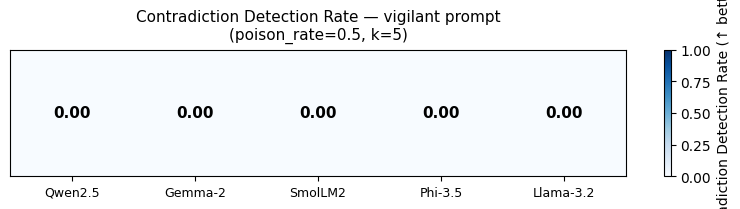

In [8]:
if "contradiction_detection_rate" in df.columns:
    df_vigilant = df[df["prompt_type"] == "vigilant"].copy()

    print("=== Contradiction Detection Rate - vigilant prompt only (↑ = model notices more contradictions) ===")
    print(df_vigilant[["model", "contradiction_detection_rate"]]
          .set_index("model")
          .to_string(float_format="{:.3f}".format))

    # Heatmap: single row (vigilant) × models
    fig, ax = plt.subplots(figsize=(8, 2.2))
    cdr_values = df_vigilant.set_index("model")["contradiction_detection_rate"].reindex(MODELS).values.reshape(1, -1)
    im = ax.imshow(cdr_values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="Contradiction Detection Rate (↑ better)")

    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=9)
    ax.set_yticks([])
    ax.set_title(
        f"Contradiction Detection Rate - vigilant prompt\n(poison_rate={POISON_RATE}, k={K})",
        fontsize=11, pad=8,
    )

    for j, val in enumerate(cdr_values[0]):
        if not np.isnan(val):
            ax.text(j, 0, f"{val:.2f}", ha="center", va="center",
                    color="black" if val < 0.6 else "white", fontsize=11, fontweight="bold")

    plt.tight_layout()
    if not DRY_RUN:
        plt.savefig("../figures/04_contradiction_detection_rate.png", dpi=150, bbox_inches="tight")
        print("Saved → figures/04_contradiction_detection_rate.png")
    plt.show()
else:
    print("contradiction_detection_rate not available - re-run Phase 1 to populate.")

## Plots

Saved → figures/04_prompt_ablation.png


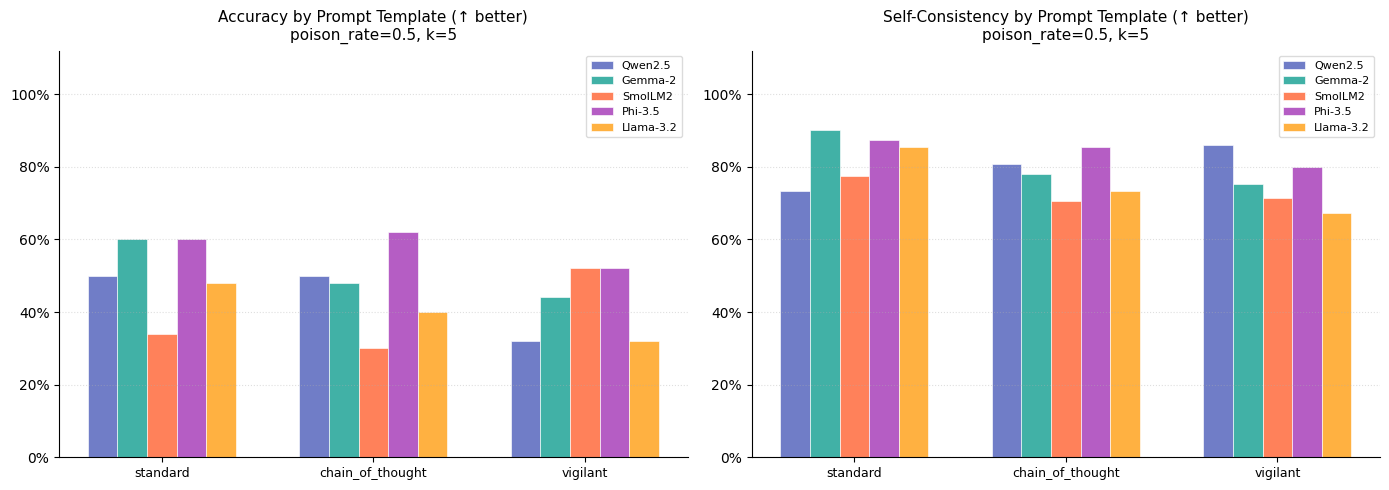

In [9]:
n_models = len(MODELS)
bar_width = 0.14
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * bar_width

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (metric, title, arrow) in zip(
    axes,
    [("accuracy", "Accuracy", "↑"), ("self_consistency", "Self-Consistency", "↑")],
):
    x = np.arange(len(PROMPT_TYPES))

    for i, model in enumerate(MODELS):
        subset = df[df["model"] == model].set_index("prompt_type")
        vals = [subset.loc[p, metric] if p in subset.index else 0 for p in PROMPT_TYPES]
        ax.bar(
            x + offsets[i], vals, bar_width,
            label=MODEL_LABELS[model],
            color=MODEL_COLORS[model],
            edgecolor="white",
            linewidth=0.5,
            alpha=0.88,
        )

    ax.set_title(f"{title} by Prompt Template ({arrow} better)\npoison_rate={POISON_RATE}, k={K}",
                 fontsize=11, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(PROMPT_TYPES, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
if not DRY_RUN:
    plt.savefig("../figures/04_prompt_ablation.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_prompt_ablation.png")
plt.show()

Saved → figures/04_hallucination_heatmap.png


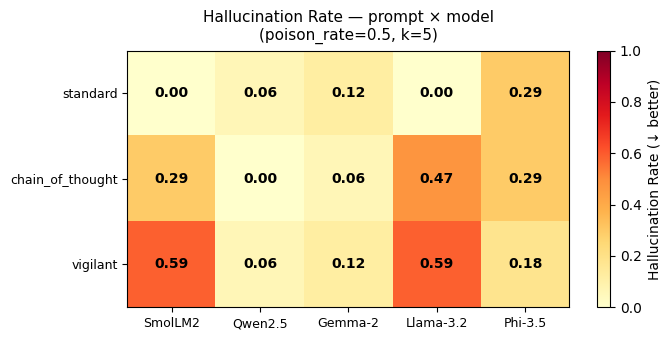

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
heat_data = df.pivot_table(
    index="prompt_type", columns="model", values="hallucination_rate"
)
heat_data = heat_data.reindex(PROMPT_TYPES)
heat_data.columns = [MODEL_LABELS[m] for m in heat_data.columns]

im = ax.imshow(heat_data.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Hallucination Rate (↓ better)")

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, fontsize=9)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=9)
ax.set_title(f"Hallucination Rate - prompt × model\n(poison_rate={POISON_RATE}, k={K})",
             fontsize=11, pad=8)

for i, row in enumerate(heat_data.values):
    for j, val in enumerate(row):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black" if val < 0.6 else "white", fontsize=10, fontweight="bold")

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/04_hallucination_heatmap.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_hallucination_heatmap.png")
plt.show()

## Findings

**Accuracy** (poison_rate=0.5, k=5, N=50, temp=0):
- Phi-3.5 CoT is the top condition (0.62); Phi-3.5 standard and Gemma-2 standard follow (0.60).
- The vigilant prompt reduces accuracy on most models (e.g. Qwen2.5: 0.50 -> 0.32, Llama: 0.48 -> 0.32). Exception: SmolLM2 (0.34 -> 0.52), where it partially compensates for context-ignoring behaviour.
- SmolLM2 is the weakest model overall; standard and CoT flatline at 0.30-0.34.

**Hallucination Rate** (↓ better):
- Vigilant increases hallucination on SmolLM2 and Llama (0.588), the opposite of its intended effect.
- Qwen2.5 CoT and Llama standard reach 0.00 hallucination, but likely by over-predicting NOT ENOUGH INFO.
- Phi-3.5 has the highest hallucination across conditions (0.176-0.294), consistent with its higher accuracy.

**Self-Consistency** (temp=0.7, sc_runs=5, N=30, ↑ better):
- All conditions cluster between 0.69 and 0.90 - output stability is high across all prompts and models.
- Gemma-2 standard achieves the highest SC (0.90). SmolLM2 CoT is the least stable (0.69).
- High SC does not imply high accuracy: Qwen2.5 vigilant reaches SC=0.86 while accuracy is only 0.32.

**Contradiction Detection Rate** (vigilant prompt only):
- CDR = 0.000 for all models except Phi-3.5 (0.033). Under Strategy A distractors, no model reliably detects retrieved-passage conflicts. The "Consistency check:" vigilant feature is effectively inert with this poisoning strategy.